In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)



In [2]:
df = pd.read_csv("METABRIC_RNA_Mutation.csv")
print("Shape:", df.shape) 

Shape: (1904, 693)


/tmp/ipykernel_426/1127961366.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [3]:
print("Column names:\n")
print(df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)

Column names:

['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 'cdk1', 'ccne1', 'cdk2', 'cdc25a', 'ccnd1', 'cdk4', 'cdk6', 'ccnd2', 'cdkn2a', 'cdkn2b', 'myc', '

In [4]:
print(df['overall_survival'].value_counts())
print("\n")
print(df['overall_survival_months'].describe())

0    1103
1     801
Name: overall_survival, dtype: int64


count    1904.000000
mean      125.121324
std        76.334148
min         0.000000
25%        60.825000
50%       115.616667
75%       184.716667
max       355.200000
Name: overall_survival_months, dtype: float64


In [5]:
clinical_cols = [col for col in df.columns if not col.endswith('_mut')]
mutation_cols = [col for col in df.columns if col.endswith('_mut')]

print("Clinical + expression columns:", len(clinical_cols))
print("Mutation columns:", len(mutation_cols))

Clinical + expression columns: 520
Mutation columns: 173

Clinical columns:
 ['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy', 'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc', 'er_status', 'neoplasm_histologic_grade', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'hormone_therapy', 'inferred_menopausal_state', 'integrative_cluster', 'primary_tumor_laterality', 'lymph_nodes_examined_positive', 'mutation_count', 'nottingham_prognostic_index', 'oncotree_code', 'overall_survival_months', 'overall_survival', 'pr_status', 'radio_therapy', '3-gene_classifier_subtype', 'tumor_size', 'tumor_stage', 'death_from_cancer', 'brca1', 'brca2', 'palb2', 'pten', 'tp53', 'atm', 'cdh1', 'chek2', 'nbn', 'nf1', 'stk11', 'bard1', 'mlh1', 'msh2', 'msh6', 'pms2', 'epcam', 'rad51c', 'rad51d', 'rad50', 'rb1', 'rbl1', 'rbl2', 'ccna1', 'ccnb1', 'cdk1', 'ccne1', 'cdk2', 'cdc25a', 

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Columns with missing values: {len(missing)}")
print("\n", missing)

Columns with missing values: 13

 tumor_stage                       501
3-gene_classifier_subtype         204
primary_tumor_laterality          106
neoplasm_histologic_grade          72
cellularity                        54
mutation_count                     45
er_status_measured_by_ihc          30
type_of_breast_surgery             22
tumor_size                         20
cancer_type_detailed               15
tumor_other_histologic_subtype     15
oncotree_code                      15
death_from_cancer                   1
dtype: int64


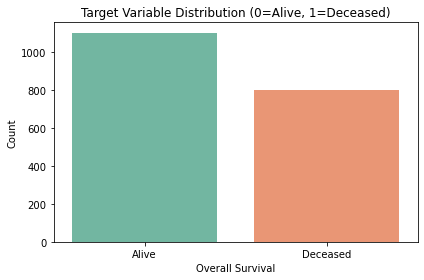

In [7]:
sns.countplot(x='overall_survival', data=df, palette='Set2')
plt.title('Target Variable Distribution (0=Alive, 1=Deceased)')
plt.xlabel('Overall Survival')
plt.ylabel('Count')
plt.xticks([0,1], ['Alive', 'Deceased'])
plt.tight_layout()
plt.show()

In [8]:
df.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,overall_survival,radio_therapy,tumor_size,tumor_stage,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,stk11,...,mecom,met,ncoa2,nrip1,pik3r3,prkci,prkd1,ran,rdh5,sdc4,serpini1,shbg,slc29a1,sox9,spry2,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,1904.000000,1904.000000,1884.000000,1403.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,0.420693,0.597164,26.238726,1.750535,-6.302521e-07,-4.201681e-07,3.676471e-07,-8.928571e-07,6.302521e-07,-2.100840e-07,0.000002,-1.175530e-16,-3.676471e-07,-0.000001,-4.726891e-07,...,-5.777311e-07,-9.978992e-07,-1.050420e-07,1.575630e-07,-3.151261e-07,-5.252101e-08,-3.151261e-07,-2.100840e-07,-1.050420e-07,-6.827731e-07,4.201681e-07,-9.978992e-07,5.252101e-08,-3.676471e-07,0.000001,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,-1.256581e-17,-1.953386e-18
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,0.493800,0.490597,15.160976,0.628999,1.000262e+00,1.000262e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000262e+00,1.000263,1.000262e+00,1.000263e+00,1.000262,1.000263e+00,...,1.000263e+00,1.000262e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000262e+00,1.000262e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000263e+00,1.000263e+00,1.000262e+00,1.000263e+00,1.000263,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262e+00,1.000262e+00
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,-2.444400e+00,-2.783500e+00,-4.384600e+00,-5.932800e+00,-2.481200e+00,-3.170500e+00,-3.323700,-2.688700e+00,-3.689800e+00,-2.968600,-3.060200e+00,...,-2.660500e+00,-2.213700e+00,-2.449700e+00,-3.527000e+00,-2.971200e+00,-3.141600e+00,-2.419500e+00,-4.307500e+00,-1.759000e+00,-3.977500e+00,-1.568800e+00,-3.467200e+00,-3.851600e+00,-2.753500e+00,-2.499500,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600e+00,-1.051600e+00
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,0.000000,0.000000,17.000000,1.000000,-7.198500e-01,-6.994750e-01,-6.798250e-01,-5.586500e-01,-6.661500e-01,-6.602250e-01,-0.458600,-7.385500e-01,-6.667750e-01,-0.683925,-6.838250e-01,...,-6.833000e-01,-6.493500e-01,-7.031250e-01,-6.198000e-01,-6.639750e-01,-6.718000e-01,-7.258750e-01,-6.147750e-01,-6.840750e-01,-6.495000e-01,-6.591000e-01,-6.425750e-01,-6.445250e-01,-6.679500e-01,-0.702875,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-4.762000e-01,-7.260000e-01
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,0.000000,1.000000,23.000000,2.000000,-1.244500e-01,-5.820000e-02,-2.210000e-02,1.098500e-01,-3.010000e-02,-4.200000e-03,0.115550,-1.311000e-01,-1.445000e-02,-0.054800,-5.785000e-02,...,-7.730000e-02,-1.401500e-01,-5.820000e-02,-2.525000e-02,-9.365000e-02,-8.490000e-02,-7.310000e-02,1.775000e-02,-1.900500e-01,-1.515000e-02,-2.632000e-01,-7.4

In [9]:
# Drop high-missing and leakage columns
cols_to_drop = [
    'tumor_stage',                    # 26% missing
    '3-gene_classifier_subtype',      # high missing
    'primary_tumor_laterality',       # high missing
    'cancer_type_detailed',           # redundant
    'oncotree_code',                  # redundant
    'tumor_other_histologic_subtype', # redundant
    'death_from_cancer'               # DATA LEAKAGE
]

df.drop(columns=cols_to_drop, inplace=True)
print("Dropped columns. New shape:", df.shape)

Dropped columns. New shape: (1904, 686)


In [10]:
# Fill missing values
# Categorical columns → fill with mode
cat_fill = ['neoplasm_histologic_grade', 'cellularity', 
            'er_status_measured_by_ihc', 'type_of_breast_surgery']

for col in cat_fill:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns → fill with median
num_fill = ['mutation_count', 'tumor_size']

for col in num_fill:
    df[col].fillna(df[col].median(), inplace=True)

print("Missing values filled!")
print("\nRemaining missing values:", df.isnull().sum().sum())

Missing values filled!

Remaining missing values: 0


In [11]:
# Confirming no missing values remain
missing_check = df.isnull().sum()
missing_check = missing_check[missing_check > 0]

if len(missing_check) == 0:
    print("✅ No missing values remaining!")
else:
    print("⚠️ Still have missing values:")
    print(missing_check)

✅ No missing values remaining!


In [12]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {len(cat_cols)}")


Categorical columns to encode: 184

 ['type_of_breast_surgery', 'cancer_type', 'cellularity', 'pam50_+_claudin-low_subtype', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'inferred_menopausal_state', 'integrative_cluster', 'pr_status', 'pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut', 'lama2_mut', 'notch1_mut', 'cbfb_mut', 'ncor2_mut', 'col12a1_mut', 'col22a1_mut', 'pten_mut', 'akt1_mut', 'atr_mut', 'thada_mut', 'ncor1_mut', 'stab2_mut', 'myh9_mut', 'runx1_mut', 'nf1_mut', 'map2k4_mut', 'ros1_mut', 'lamb3_mut', 'arid1b_mut', 'erbb2_mut', 'sf3b1_mut', 'shank2_mut', 'ep300_mut', 'ptprd_mut', 'usp9x_mut', 'setd2_mut', 'setd1a_mut', 'thsd7a_mut', 'afdn_mut', 'erbb3_mut', 'rb1_m

In [13]:
# Checking unique values in each categorical column to know which encoding method to use
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values → {df[col].unique()}")

type_of_breast_surgery: 2 unique values → ['MASTECTOMY' 'BREAST CONSERVING']
cancer_type: 2 unique values → ['Breast Cancer' 'Breast Sarcoma']
cellularity: 3 unique values → ['High' 'Moderate' 'Low']
pam50_+_claudin-low_subtype: 7 unique values → ['claudin-low' 'LumA' 'LumB' 'Her2' 'Normal' 'Basal' 'NC']
er_status_measured_by_ihc: 2 unique values → ['Positve' 'Negative']
er_status: 2 unique values → ['Positive' 'Negative']
her2_status_measured_by_snp6: 4 unique values → ['NEUTRAL' 'LOSS' 'GAIN' 'UNDEF']
her2_status: 2 unique values → ['Negative' 'Positive']
inferred_menopausal_state: 2 unique values → ['Post' 'Pre']
integrative_cluster: 11 unique values → ['4ER+' '3' '9' '7' '4ER-' '5' '8' '10' '1' '2' '6']
pr_status: 2 unique values → ['Negative' 'Positive']
pik3ca_mut: 160 unique values → ['0' 'H1047R' 'E542K' 'Q546H G1049R' 'E545K' 'N345K E81K' 'H1047L E726K'
 'H1047L' 'E545Q' 'N345K' 'L452Kfs*4 E453Dfs*7' 'N345K N1044K'
 'E365K C420R' 'E545K H1047R' 'E542K E726K' 'E453_L455del' 'G4

In [14]:
# Encode binary columns (only 2 unique values) with Label Encoding
# and multi-class columns with One-Hot Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# separate binary vs multi-category columns
binary_cats = [col for col in cat_cols if df[col].nunique() == 2]
multi_cats  = [col for col in cat_cols if df[col].nunique() > 2]

print("Binary categorical columns:", binary_cats)
print("\nMulti-category columns:", multi_cats)

Binary categorical columns: ['type_of_breast_surgery', 'cancer_type', 'er_status_measured_by_ihc', 'er_status', 'her2_status', 'inferred_menopausal_state', 'pr_status']

Multi-category columns: ['cellularity', 'pam50_+_claudin-low_subtype', 'her2_status_measured_by_snp6', 'integrative_cluster', 'pik3ca_mut', 'tp53_mut', 'muc16_mut', 'ahnak2_mut', 'kmt2c_mut', 'syne1_mut', 'gata3_mut', 'map3k1_mut', 'ahnak_mut', 'dnah11_mut', 'cdh1_mut', 'dnah2_mut', 'kmt2d_mut', 'ush2a_mut', 'ryr2_mut', 'dnah5_mut', 'herc2_mut', 'pde4dip_mut', 'akap9_mut', 'tg_mut', 'birc6_mut', 'utrn_mut', 'tbx3_mut', 'col6a3_mut', 'arid1a_mut', 'lama2_mut', 'notch1_mut', 'cbfb_mut', 'ncor2_mut', 'col12a1_mut', 'col22a1_mut', 'pten_mut', 'akt1_mut', 'atr_mut', 'thada_mut', 'ncor1_mut', 'stab2_mut', 'myh9_mut', 'runx1_mut', 'nf1_mut', 'map2k4_mut', 'ros1_mut', 'lamb3_mut', 'arid1b_mut', 'erbb2_mut', 'sf3b1_mut', 'shank2_mut', 'ep300_mut', 'ptprd_mut', 'usp9x_mut', 'setd2_mut', 'setd1a_mut', 'thsd7a_mut', 'afdn_mut', 'e

In [15]:
# Convert all _mut columns to binary (0 = no mutation, 1 = mutated)
mut_cols = [col for col in df.columns if col.endswith('_mut')]

for col in mut_cols:
    df[col] = df[col].apply(lambda x: 0 if str(x).strip() == '0' else 1)

print("Mutation columns converted to binary!")
print(f"Sample check:\n{df[mut_cols[:5]].head()}")

Mutation columns converted to binary!
Sample check:
   pik3ca_mut  tp53_mut  muc16_mut  ahnak2_mut  kmt2c_mut
0           0         0          0           0          0
1           0         1          0           0          0
2           1         0          0           0          0
3           1         0          0           0          0
4           0         1          0           0          0


In [16]:
# Encoding binary categorical columns with Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cats = [col for col in cat_cols if df[col].nunique() == 2]

for col in binary_cats:
    df[col] = le.fit_transform(df[col])

print("Binary columns encoded!")
print(df[binary_cats].head())

Binary columns encoded!
   type_of_breast_surgery  cancer_type  er_status_measured_by_ihc  er_status  her2_status  inferred_menopausal_state  pr_status  pik3ca_mut  tp53_mut  muc16_mut  ahnak2_mut  kmt2c_mut  syne1_mut  gata3_mut  map3k1_mut  ahnak_mut  dnah11_mut  cdh1_mut  dnah2_mut  kmt2d_mut  ush2a_mut  ryr2_mut  dnah5_mut  herc2_mut  pde4dip_mut  ...  foxo1_mut  nt5e_mut  ccnd3_mut  nr3c1_mut  prkg1_mut  tbl1xr1_mut  frmd3_mut  smad2_mut  sgcd_mut  spaca1_mut  rasgef1b_mut  hist1h2bc_mut  nr2f1_mut  klrg1_mut  mbl2_mut  mtap_mut  ppp2cb_mut  smarcd1_mut  nras_mut  ndfip1_mut  hras_mut  prps2_mut  smarcb1_mut  stmn2_mut  siah1_mut
0                       1            0                          1          1            0                          0          0           0         0          0           0          0          0          0           0          0           0         0          0          0          0         0          0          0            0  ...          0         0   

In [17]:
# Encode ordinal column (cellularity) manually
# Low=1, Moderate=2, High=3
df['cellularity'] = df['cellularity'].map({'Low': 1, 'Moderate': 2, 'High': 3})

# One-hot encode remaining multi-category columns
multi_cats = ['pam50_+_claudin-low_subtype', 'her2_status_measured_by_snp6', 
              'integrative_cluster']

df = pd.get_dummies(df, columns=multi_cats, drop_first=True)

print("New dataframe shape:", df.shape)

Ordinal + multi-category columns encoded!
New dataframe shape: (1904, 702)


In [18]:
# Final check: confirming no object columns remain
remaining_objects = df.select_dtypes(include='object').columns.tolist()

if len(remaining_objects) == 0:
    print("✅ All columns are now numeric — ready for ML!")
else:
    print(remaining_objects)

✅ All columns are now numeric — ready for ML!


In [19]:
# Separate features (X) and target (y)
# Dropping overall_survival_months because it's directly related to our target

X = df.drop(columns=['overall_survival', 'overall_survival_months', 'patient_id'])
y = df['overall_survival']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Features shape: (1904, 699)
Target shape: (1904,)

Target distribution:
0    1103
1     801
Name: overall_survival, dtype: int64


In [20]:
# Remove highly correlated features
# Features correlated > 0.95 are redundant 

corr_matrix = X.corr().abs()

# Get upper triangle of correlation matrix
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find columns with correlation > 0.95
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Highly correlated columns to drop: {len(to_drop_corr)}")
print(to_drop_corr)

X.drop(columns=to_drop_corr, inplace=True)
print("\nShape after dropping correlated features:", X.shape)

Highly correlated columns to drop: 0
[]

Shape after dropping correlated features: (1904, 699)


In [21]:
# Mutual Information Feature Selection
# Ranks every feature by how much information it shares with survival outcome
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

print("Top 20 most informative features:")
print(mi_df.head(20))

Top 20 most informative features:
                         Feature  MI_Score
0               age_at_diagnosis  0.062240
14   nottingham_prognostic_index  0.056755
396                         nras  0.043034
65                          jak1  0.033256
264                         rps6  0.031936
203                       map2k2  0.031134
385                         men1  0.030790
469                     hsd17b11  0.029818
376                        lama2  0.029678
377                        lamb3  0.028966
303                      pde4dip  0.028415
476                      hsd17b6  0.028409
496                        spry2  0.028237
308                        abcb1  0.027844
18                         brca1  0.026920
220                         mdc1  0.026883
275                        smad5  0.026579
141                       bcl2l1  0.026109
133                       akt1s1  0.025988
421                         sgcd  0.025928


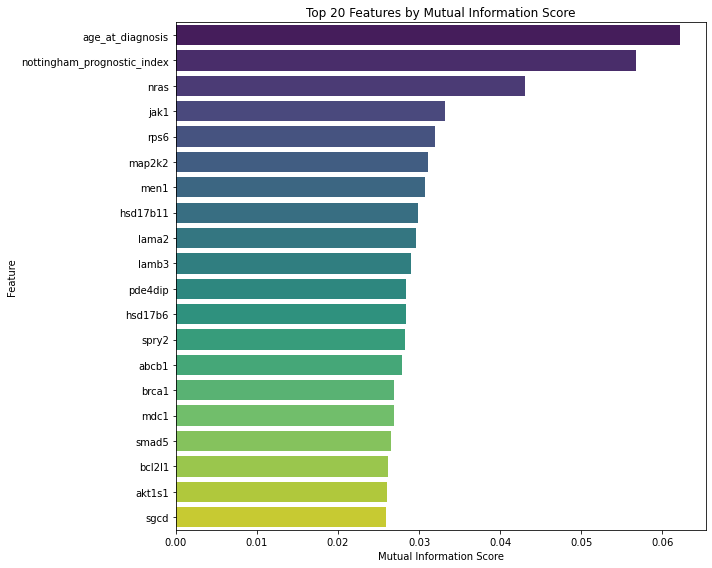

In [22]:
# Visualizing top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(data=mi_df.head(20), x='MI_Score', y='Feature', palette='viridis')
plt.title('Top 20 Features by Mutual Information Score')
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

In [23]:
# Keep top 50 features for modelling
top_features = mi_df.head(50)['Feature'].tolist()

X_selected = X[top_features]

print("Final feature set shape:", X_selected.shape)
print("\nSelected features:")
print(top_features)

Final feature set shape: (1904, 50)

Selected features:
['age_at_diagnosis', 'nottingham_prognostic_index', 'nras', 'jak1', 'rps6', 'map2k2', 'men1', 'hsd17b11', 'lama2', 'lamb3', 'pde4dip', 'hsd17b6', 'spry2', 'abcb1', 'brca1', 'mdc1', 'smad5', 'bcl2l1', 'akt1s1', 'sgcd', 'pdgfb', 'rdh5', 'rad50', 'serpini1', 'runx1', 'acvrl1', 'cohort', 'myh9', 'maml3', 'mmp16', 'folr2', 'folr1', 'cacna2d3', 'jag1', 'brca2_mut', 'map2k5', 'kit', 'smad4', 'akt3', 'cdc25a', 'mmp12', 'pten_mut', 'l1cam', 'gh1', 'ncoa3', 'fas', 'sdc4', 'afdn_mut', 'slc29a1', 'type_of_breast_surgery']


In [24]:
#  Train/Test Split (80/20, stratified)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())

Training set shape: (1523, 50)
Test set shape: (381, 50)

Training target distribution:
0    882
1    641
Name: overall_survival, dtype: int64

Test target distribution:
0    221
1    160
Name: overall_survival, dtype: int64


In [25]:
# Scaling the features, Important for Logistic Regression and Neural Networks
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to dataframe so we keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=top_features)
X_test_scaled  = pd.DataFrame(X_test_scaled, columns=top_features)

print("✅ Scaling complete!")
print("Training set mean :", round(X_train_scaled.mean().mean(), 4))
print("Training set std:", round(X_train_scaled.std().mean(), 4))

✅ Scaling complete!
Training set mean (should be ~0): 0.0
Training set std (should be ~1): 1.0003


In [26]:
# Logistic Regression 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             classification_report, confusion_matrix)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Alive', 'Deceased']))

=== Logistic Regression ===
Accuracy:  0.6640
ROC-AUC:   0.7193

Classification Report:
              precision    recall  f1-score   support

       Alive       0.70      0.73      0.72       221
    Deceased       0.61      0.57      0.59       160

    accuracy                           0.66       381
   macro avg       0.65      0.65      0.65       381
weighted avg       0.66      0.66      0.66       381



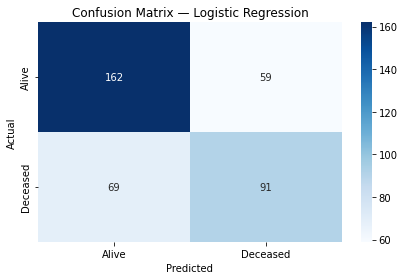

In [27]:
# Confusion Matrix for Logistic Regression
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive', 'Deceased'],
            yticklabels=['Alive', 'Deceased'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [28]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Alive', 'Deceased']))

=== Random Forest ===
Accuracy:  0.6877
ROC-AUC:   0.7466

Classification Report:
              precision    recall  f1-score   support

       Alive       0.69      0.84      0.76       221
    Deceased       0.68      0.48      0.56       160

    accuracy                           0.69       381
   macro avg       0.69      0.66      0.66       381
weighted avg       0.69      0.69      0.68       381



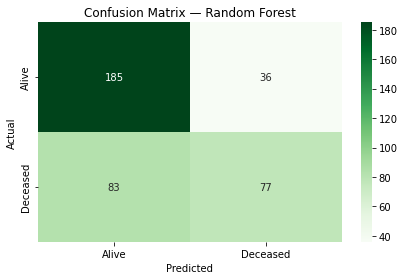

In [29]:
# Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Alive', 'Deceased'],
            yticklabels=['Alive', 'Deceased'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

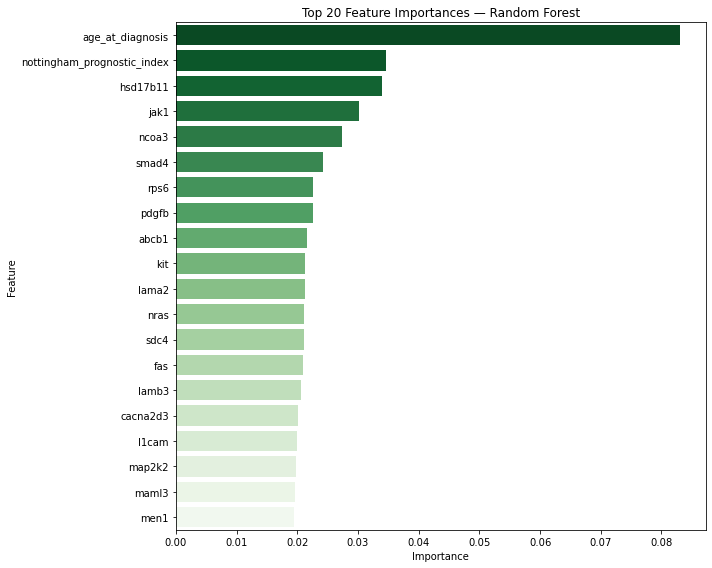

Top 10 features:
                        Feature  Importance
0              age_at_diagnosis    0.083115
1   nottingham_prognostic_index    0.034671
7                      hsd17b11    0.033999
3                          jak1    0.030137
44                        ncoa3    0.027361
37                        smad4    0.024167
4                          rps6    0.022604
20                        pdgfb    0.022558
13                        abcb1    0.021547
36                          kit    0.021337


In [30]:
# Random Forest Feature Importance
# This is built into Random Forest — shows which features it found most useful
feat_imp = pd.DataFrame({
    'Feature': top_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='Importance', y='Feature', palette='Greens_r')
plt.title('Top 20 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_imp.head(10))

In [31]:
import sys
!{sys.executable} -m pip install xgboost


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [32]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Alive', 'Deceased']))

=== XGBoost ===
Accuracy:  0.6850
ROC-AUC:   0.7442

Classification Report:
              precision    recall  f1-score   support

       Alive       0.72      0.75      0.73       221
    Deceased       0.63      0.59      0.61       160

    accuracy                           0.69       381
   macro avg       0.68      0.67      0.67       381
weighted avg       0.68      0.69      0.68       381



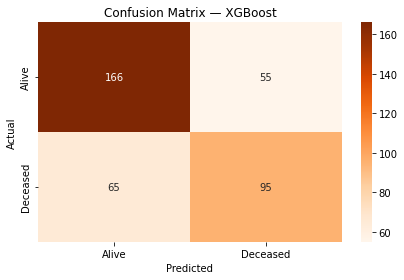

In [33]:
# Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Alive', 'Deceased'],
            yticklabels=['Alive', 'Deceased'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

                 Model  Accuracy  ROC-AUC
0  Logistic Regression    0.6640   0.7193
1        Random Forest    0.6877   0.7466
2              XGBoost    0.6850   0.7442


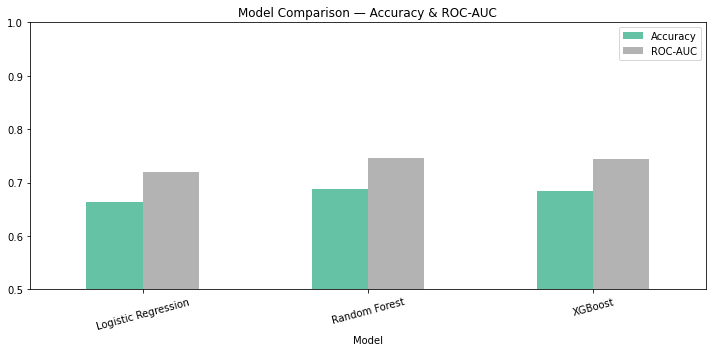

In [34]:
# Comparing all three models
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print(results.round(4))

# Visual comparison
results.plot(x='Model', kind='bar', figsize=(10, 5), 
             colormap='Set2', ylim=(0.5, 1.0))
plt.title('Model Comparison — Accuracy & ROC-AUC')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [35]:
# Neural Network 
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,          # stops if no improvement
    validation_fraction=0.1
)

nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)
y_prob_nn = nn.predict_proba(X_test_scaled)[:, 1]

print("=== Neural Network ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_nn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn, target_names=['Alive', 'Deceased']))

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warni

=== Neural Network ===
Accuracy:  0.6325
ROC-AUC:   0.6819

Classification Report:
              precision    recall  f1-score   support

       Alive       0.67      0.71      0.69       221
    Deceased       0.57      0.52      0.54       160

    accuracy                           0.63       381
   macro avg       0.62      0.62      0.62       381
weighted avg       0.63      0.63      0.63       381



/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warni

                 Model  Accuracy  ROC-AUC
0  Logistic Regression    0.6640   0.7193
1        Random Forest    0.6877   0.7466
2              XGBoost    0.6850   0.7442
3       Neural Network    0.6325   0.6819


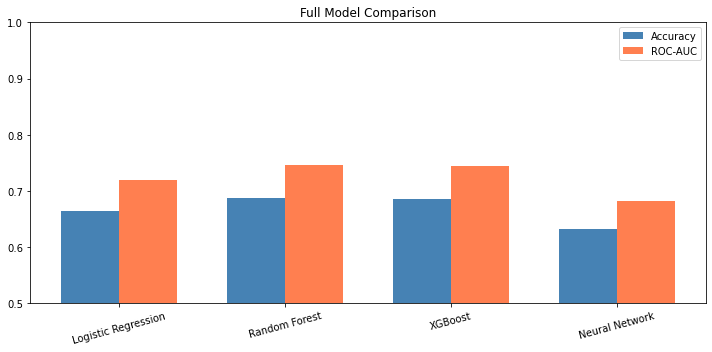

In [36]:
#  Full model comparison including Neural Network
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_nn)
    ]
})

print(results.round(4))

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, results['ROC-AUC'], width, label='ROC-AUC', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15)
ax.set_ylim(0.5, 1.0)
ax.set_title('Full Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [37]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [38]:
#  SHAP Setup
import shap

# Use Random Forest — our best model
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP values computed successfully!")
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values computed successfully!
SHAP values shape: (381, 50, 2)


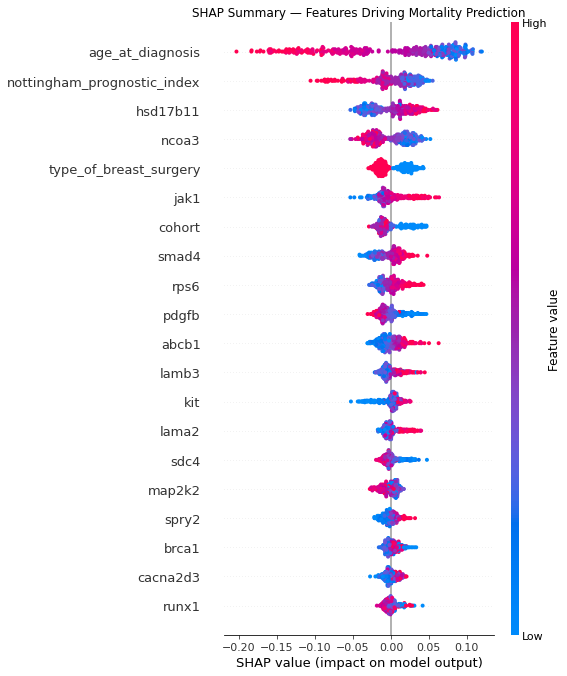

In [39]:
#  SHAP Summary Dot Plot
shap_values_deceased = shap_values[:, :, 1]  # Extract Deceased class

plt.figure()
shap.summary_plot(
    shap_values_deceased,
    X_test_scaled,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Features Driving Mortality Prediction")
plt.tight_layout()
plt.show()

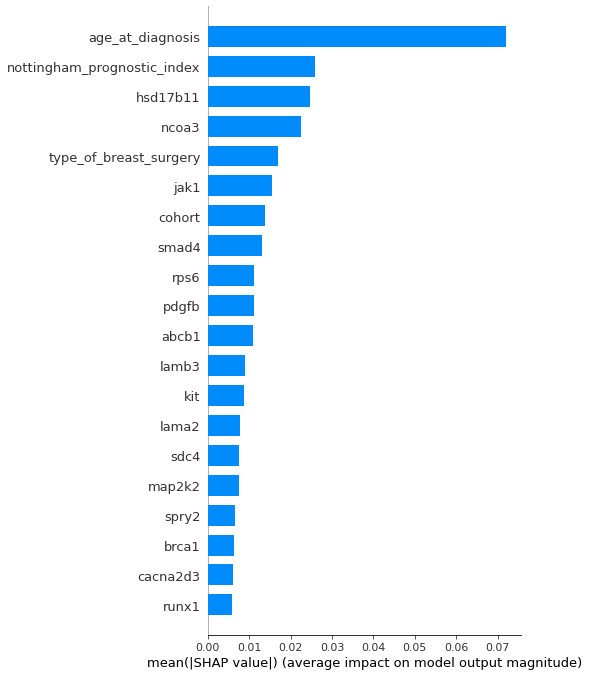

In [40]:
# SHAP Bar Plot
shap.summary_plot(
    shap_values_deceased,
    X_test_scaled,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.tight_layout()
plt.show()

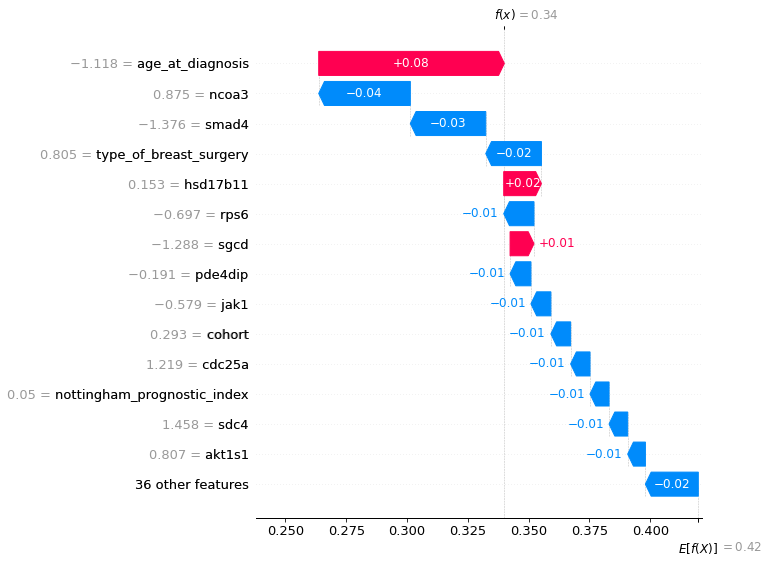

<Figure size 432x288 with 0 Axes>

In [41]:
# SHAP Waterfall plot for a single patient
# This shows WHY the model made a specific prediction for one patient
# Very impressive for presentations
explainer_single = shap.TreeExplainer(rf)
shap_explanation = explainer_single(X_test_scaled)

shap.plots.waterfall(shap_explanation[:, :, 1][0], max_display=15)
plt.tight_layout()
plt.show()

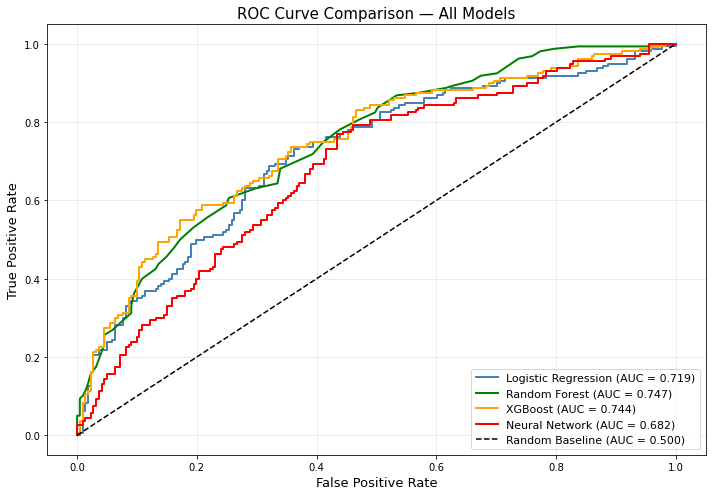

In [42]:
# ROC Curves for all 4 models
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

models = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'Neural Network': y_prob_nn
}

colors = ['steelblue', 'green', 'orange', 'red']

for (name, prob), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve Comparison — All Models', fontsize=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Cross Validation on best model (Random Forest)
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf, X_selected, y, 
                             cv=cv, scoring='roc_auc', n_jobs=-1)

print("=== 5-Fold Cross Validation — Random Forest ===")
print(f"AUC per fold: {cv_scores.round(4)}")
print(f"Mean AUC:     {cv_scores.mean():.4f}")
print(f"Std Dev:      {cv_scores.std():.4f}")
print(f"\nThis means our model performs between "
      f"{(cv_scores.mean() - cv_scores.std()):.4f} and "
      f"{(cv_scores.mean() + cv_scores.std()):.4f} AUC on unseen data")

=== 5-Fold Cross Validation — Random Forest ===
AUC per fold: [0.7234 0.7561 0.7526 0.7467 0.758 ]
Mean AUC:     0.7474
Std Dev:      0.0126

This means our model performs between 0.7348 and 0.7600 AUC on unseen data


In [44]:
# Save the trained model and scaler
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved as: random_forest_model.pkl")
print("✅ Scaler saved as: scaler.pkl")

✅ Model saved as: random_forest_model.pkl
✅ Scaler saved as: scaler.pkl


In [45]:
#  Save results summary
results_final = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_nn)
    ],
    'CV_AUC_Mean': [None, cv_scores.mean(), None, None],
    'CV_AUC_Std':  [None, cv_scores.std(),  None, None]
})

results_final = results_final.round(4)
results_final.to_csv('model_results.csv', index=False)

print("✅ Results saved as: model_results.csv")
print("\n", results_final)

✅ Results saved as: model_results.csv

                  Model  Accuracy  ROC-AUC  CV_AUC_Mean  CV_AUC_Std
0  Logistic Regression    0.6640   0.7193          NaN         NaN
1        Random Forest    0.6877   0.7466       0.7474      0.0126
2              XGBoost    0.6850   0.7442          NaN         NaN
3       Neural Network    0.6325   0.6819          NaN         NaN


In [46]:
# Verify all files are saved
import os

files = ['random_forest_model.pkl', 'scaler.pkl', 'model_results.csv']
for f in files:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")

✅ random_forest_model.pkl
✅ scaler.pkl
✅ model_results.csv
